# Cluster-Local DQN Models — 10 Clusters from 300 Ausgrid Households

Trains a **separate DQN agent per cluster** (10 clusters from `cluster_10` k-means result).  
Each cluster agent trains only on the users assigned to that cluster.

**Evaluation strategy:**
- **All clusters**: one designated eval user evaluated on the test split (last 1/3 of data).  
- **Small clusters (8 of 10)**: eval user is the cluster centroid-nearest user and **is included in training** (seen).  
- **Two largest clusters** (cluster 5 = 62 users, cluster 1 = 43 users): eval user is **held out from training** entirely (unseen), mirroring the global model.

Comparison for each cluster: No-Battery Baseline vs Cluster DQN vs MILP Theoretical Optimum.

## Cell 1 — Imports & device

In [1]:
import os
import sys
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pulp

import torch as T
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from sklearn.preprocessing import RobustScaler

import Environment as environment_module
importlib.reload(environment_module)
HouseholdEnvironment = environment_module.HouseholdEnvironment

from Basic_Functions import (
    calculate_interval_price,
    run_milp_benchmark,
    milp_total_cost,
)

if T.cuda.is_available():
    device = T.device('cuda')
    print(f'NVIDIA CUDA: {T.cuda.get_device_name(0)}')
elif T.backends.mps.is_available():
    device = T.device('mps')
    print('Apple Silicon MPS')
else:
    device = T.device('cpu')
    print('CPU')

Apple Silicon MPS


## Cell 2 — Configuration

In [2]:
# ── Experiment ──────────────────────────────────────────────
SEED          = 42
CLUSTER_FILE  = 'clustering_results/user_ids_sorted_by_cluster_10.csv'
N_TOP_HOLDOUT = 2   # top-N largest clusters get a held-out eval user
DATA_DIR      = 'Datasorted by user'

# ── Physics (30-min step) ───────────────────────────────────
BASE_STEP_MINUTES    = 15.0
DATASET_STEP_MINUTES = 30.0
step_scale           = DATASET_STEP_MINUTES / BASE_STEP_MINUTES  # 2.0

KorakovNaDan     = int(round(1440 / DATASET_STEP_MINUTES))  # 48
BatKapaciteta    = 20.0
BatUcinkovitost  = 0.95
BatMaxPolnjenje  = 1.5 * step_scale   # 3.0 kWh/step
BatMaxPraznjenje = 1.5 * step_scale   # 3.0 kWh/step
faktorN1, faktorN2, faktorN3 = 0, 0, 1

# ── DQN hyper-parameters ────────────────────────────────────
fc1_dims, fc2_dims, fc3_dims, fc4_dims = 256, 128, 64, 32
lr             = 0.001
gamma          = 0.99
epsilon_start  = 1.0
epsilon_end    = 0.01
epsilon_decay  = 4e-5 / 4
batch_size     = 48
replace_target = KorakovNaDan * 7   # 336 steps
weight_decay   = 1e-4

# ── Training schedule ───────────────────────────────────────
N_ROUNDS           = 40 * 4   # 160 rounds (same as global model)
EPISODES_PER_ROUND = 10
EPISODE_STEPS      = KorakovNaDan * 7  # 336 steps = 1 week

print(f'KorakovNaDan={KorakovNaDan}  BatMaxPol={BatMaxPolnjenje}  BatMaxPra={BatMaxPraznjenje}')
print(f'Training: {N_ROUNDS} rounds × {EPISODES_PER_ROUND} eps × {EPISODE_STEPS} steps/ep')

KorakovNaDan=48  BatMaxPol=3.0  BatMaxPra=3.0
Training: 160 rounds × 10 eps × 336 steps/ep


## Cell 3 — Load cluster assignments & define train/eval splits per cluster

In [3]:
rng = np.random.default_rng(SEED)

cluster_df = pd.read_csv(CLUSTER_FILE)
cluster_df['uid'] = cluster_df['user_id'].str.extract(r'(\d+)').astype(int)

# Identify the N_TOP_HOLDOUT largest clusters
cluster_sizes = cluster_df.groupby('cluster').size().sort_values(ascending=False)
top_clusters  = cluster_sizes.index[:N_TOP_HOLDOUT].tolist()  # e.g. [5, 1]

print('Cluster sizes (descending):')
for c, n in cluster_sizes.items():
    tag = ' ← HOLDOUT eval user' if c in top_clusters else ''
    print(f'  Cluster {c:2d}: {n:3d} users{tag}')

# Build per-cluster user lists
all_cluster_ids    = sorted(cluster_df['cluster'].unique())
cluster_all_uids   = {}  # all uids in cluster
cluster_train_uids = {}  # uids used for training
cluster_eval_uid   = {}  # single uid used for evaluation

for c in all_cluster_ids:
    uids = (cluster_df[cluster_df['cluster'] == c]
            .sort_values('rank_in_cluster')['uid']
            .tolist())
    cluster_all_uids[c] = uids
    eval_uid = uids[0]   # closest to centroid → most representative of cluster
    cluster_eval_uid[c]  = eval_uid
    if c in top_clusters:
        cluster_train_uids[c] = [u for u in uids if u != eval_uid]
    else:
        cluster_train_uids[c] = uids  # eval uid is included in training

print('\nEval user per cluster:')
for c in all_cluster_ids:
    group = 'holdout' if c in top_clusters else 'seen'
    print(f'  Cluster {c:2d}: eval_uid={cluster_eval_uid[c]:3d} ({group:7s}), '
          f'train_users={len(cluster_train_uids[c])}')

Cluster sizes (descending):
  Cluster  5:  62 users ← HOLDOUT eval user
  Cluster  1:  43 users ← HOLDOUT eval user
  Cluster  0:  42 users
  Cluster  6:  37 users
  Cluster  4:  32 users
  Cluster  2:  31 users
  Cluster  8:  20 users
  Cluster  9:  14 users
  Cluster  3:  11 users
  Cluster  7:   8 users

Eval user per cluster:
  Cluster  0: eval_uid=259 (seen   ), train_users=42
  Cluster  1: eval_uid= 28 (holdout), train_users=42
  Cluster  2: eval_uid= 31 (seen   ), train_users=31
  Cluster  3: eval_uid=287 (seen   ), train_users=11
  Cluster  4: eval_uid=243 (seen   ), train_users=32
  Cluster  5: eval_uid= 66 (holdout), train_users=61
  Cluster  6: eval_uid=200 (seen   ), train_users=37
  Cluster  7: eval_uid=251 (seen   ), train_users=8
  Cluster  8: eval_uid= 78 (seen   ), train_users=20
  Cluster  9: eval_uid=249 (seen   ), train_users=14


## Cell 4 — Load & split all 300 datasets

In [4]:
def load_ausgrid(uid):
    path = os.path.join(DATA_DIR, f'Ausgrid {uid}.csv')
    df = pd.read_csv(path)
    df.index = pd.to_datetime(df['Timestamp_UTC'], format='ISO8601')
    df = df.drop(columns=['Timestamp_UTC'])
    return df

print('Loading 300 datasets...')
train_dfs = {}
test_dfs  = {}

for uid in range(1, 301):
    df = load_ausgrid(uid)
    split = int(len(df) * 2 / 3)
    train_dfs[uid] = df.iloc[:split].copy()
    test_dfs[uid]  = df.iloc[split:].copy()

sample = train_dfs[1]
print(f'Loaded. Train rows: {len(sample)}  Test rows: {len(test_dfs[1])}')
print(f'Columns: {sample.columns.tolist()}')
print(f'Date range (train user 1): {sample.index[0]} → {sample.index[-1]}')

Loading 300 datasets...
Loaded. Train rows: 35072  Test rows: 17536
Columns: ['Energy_Consumption', 'Energy_Generation', 'SMP']
Date range (train user 1): 2010-07-01 00:30:00+00:00 → 2012-06-30 16:00:00+00:00


## Cell 5 — Per-cluster normalization

Each cluster's energy scaler is fitted **only on that cluster's training users** so that the model generalises within its cluster distribution. The SMP price scaler is shared (SMP is identical across all users).

In [5]:
shared_cols = ['Energy_Generation', 'Energy_Consumption']

def normalize_electricity_prices(data, fit=False, params=None):
    """Log + clip + RobustScaler for SMP."""
    if data.ndim == 1:
        data = data.reshape(-1, 1)
    if fit:
        upper_threshold = np.percentile(data, 99.5)
        lower_threshold = np.percentile(data, 0.1)
    else:
        upper_threshold = params['upper_threshold']
        lower_threshold = params['lower_threshold']

    outlier_flag = ((data > upper_threshold) | (data < lower_threshold)).astype(float)
    log_data     = np.log1p(np.maximum(data, 0))
    log_lower    = np.log1p(max(0, lower_threshold))
    log_upper    = np.log1p(max(0, upper_threshold))
    clipped      = np.clip(log_data, log_lower, log_upper)

    if fit:
        scaler = RobustScaler()
        normalized = scaler.fit_transform(clipped)
        fitted_params = {
            'upper_threshold': float(upper_threshold),
            'lower_threshold': float(lower_threshold),
            'log_lower': float(log_lower),
            'log_upper': float(log_upper),
            'scaler': scaler,
        }
    else:
        normalized    = params['scaler'].transform(clipped)
        fitted_params = params

    return normalized, outlier_flag, fitted_params

# SMP scaler: fit once on any user's training data (SMP is identical for all)
_ref_uid = cluster_all_uids[all_cluster_ids[0]][0]
_, _, price_norm_params = normalize_electricity_prices(train_dfs[_ref_uid]['SMP'].values, fit=True)
print('SMP price scaler fitted (shared across all clusters).')

def apply_normalization(df, energy_scaler, price_params):
    df_n = df.copy()
    for col in shared_cols:
        df_n[col] = energy_scaler.transform(df[col].values.reshape(-1, 1)).flatten()
    smp_norm, smp_flag, _ = normalize_electricity_prices(
        df['SMP'].values, fit=False, params=price_params)
    df_n['SMP'] = smp_norm.flatten()
    df_n['SMP_OutlierFlag'] = smp_flag.flatten()
    return df_n

# Fit per-cluster energy scaler; normalize all cluster users
cluster_energy_scalers = {}
cluster_train_norm_dfs = {}   # cluster_id -> {uid: normalized_train_df}
cluster_test_norm_dfs  = {}   # cluster_id -> {uid: normalized_test_df}

print('Building per-cluster energy scalers and normalising datasets...')
for c in all_cluster_ids:
    t_uids  = cluster_train_uids[c]   # users that contribute to scaler fit
    all_uids = cluster_all_uids[c]

    combined = np.concatenate([
        train_dfs[uid][shared_cols].values.flatten()
        for uid in t_uids
    ]).reshape(-1, 1)
    scaler = RobustScaler().fit(combined)
    cluster_energy_scalers[c] = scaler

    cluster_train_norm_dfs[c] = {
        uid: apply_normalization(train_dfs[uid], scaler, price_norm_params)
        for uid in all_uids
    }
    cluster_test_norm_dfs[c] = {
        uid: apply_normalization(test_dfs[uid], scaler, price_norm_params)
        for uid in all_uids
    }
    print(f'  Cluster {c:2d}: scaler fitted on {len(t_uids):2d} users, '
          f'normalised {len(all_uids):2d} users.')

print('Done.')

SMP price scaler fitted (shared across all clusters).
Building per-cluster energy scalers and normalising datasets...
  Cluster  0: scaler fitted on 42 users, normalised 42 users.
  Cluster  1: scaler fitted on 42 users, normalised 43 users.
  Cluster  2: scaler fitted on 31 users, normalised 31 users.
  Cluster  3: scaler fitted on 11 users, normalised 11 users.
  Cluster  4: scaler fitted on 32 users, normalised 32 users.
  Cluster  5: scaler fitted on 61 users, normalised 62 users.
  Cluster  6: scaler fitted on 37 users, normalised 37 users.
  Cluster  7: scaler fitted on  8 users, normalised  8 users.
  Cluster  8: scaler fitted on 20 users, normalised 20 users.
  Cluster  9: scaler fitted on 14 users, normalised 14 users.
Done.


## Cell 6 — Environment factory

In [6]:
def make_env(uid, cluster_id, split='train', episode_length=None):
    """Create a HouseholdEnvironment using cluster-specific normalization."""
    if split == 'train':
        data       = train_dfs[uid]
        data_n     = cluster_train_norm_dfs[cluster_id][uid]
        reset_mode = 'random'
        ep_len     = episode_length if episode_length is not None else EPISODE_STEPS
    else:
        data       = test_dfs[uid]
        data_n     = cluster_test_norm_dfs[cluster_id][uid]
        reset_mode = 'deterministic'
        ep_len     = episode_length if episode_length is not None else len(data) - 1

    return HouseholdEnvironment(
        dataset            = data,
        dataset_norm       = data_n,
        observation_mode   = 'sliding_window',
        reset_mode         = reset_mode,
        episode_length     = ep_len,
        korakov_na_dan     = KorakovNaDan,
        bat_kapaciteta     = BatKapaciteta,
        bat_ucinkovitost   = BatUcinkovitost,
        bat_max_polnjenje  = BatMaxPolnjenje,
        bat_max_praznjenje = BatMaxPraznjenje,
        faktor_n1 = faktorN1,
        faktor_n2 = faktorN2,
        faktor_n3 = faktorN3,
    )

_tmp_env = make_env(cluster_all_uids[all_cluster_ids[0]][0], all_cluster_ids[0], split='train')
STATE_DIM = int(_tmp_env.observation_space.shape[0])
print(f'State dim: {STATE_DIM}  '
      f'(window_past={_tmp_env.window_past}, window_future={_tmp_env.window_future})')

State dim: 25  (window_past=0, window_future=22)


## Cell 7 — DQN agent (identical to global model)

In [7]:
class DeepQNetwork(nn.Module):
    def __init__(self, lr, layer_dims, weight_decay=1e-4):
        super().__init__()
        self.layer_dims = list(layer_dims)
        self.layers = nn.ModuleList([
            nn.Linear(in_d, out_d)
            for in_d, out_d in zip(self.layer_dims[:-1], self.layer_dims[1:])
        ])
        self.optimizer = optim.AdamW(self.parameters(), lr=lr, weight_decay=weight_decay)
        self.loss = nn.SmoothL1Loss(beta=1.0)
        self.device = T.device('cuda' if T.cuda.is_available() else
                               'mps'  if T.backends.mps.is_available() else 'cpu')
        nn.init.constant_(self.layers[-1].bias, 0.1)
        self.to(self.device)

    def forward(self, state):
        x = state
        for layer in self.layers[:-1]:
            x = F.relu(layer(x))
        return self.layers[-1](x)


class AgentDQN:
    def __init__(self, gamma, epsilon, lr, state_shape, network_dims,
                 batch_size, replace_target=336, max_mem_size=1_000_000,
                 eps_end=0.05, eps_dec=4e-5, weight_decay=1e-4, tau=0.005):
        self.gamma          = gamma
        self.epsilon        = epsilon
        self.eps_min        = eps_end
        self.eps_dec        = eps_dec
        self.lr             = lr
        self.batch_size     = batch_size
        self.mem_size       = max_mem_size
        self.mem_cntr       = 0
        self.iter_cntr      = 0
        self.replace_target = replace_target
        self.tau            = float(tau)
        self.state_shape    = list(state_shape)
        self.network_dims   = list(network_dims)
        self.n_actions      = self.network_dims[-1]
        self.action_space   = list(range(self.n_actions))
        self.start_learning_after = int(4 * batch_size)

        self.Q_eval   = DeepQNetwork(lr=lr, layer_dims=self.network_dims, weight_decay=weight_decay)
        self.Q_target = DeepQNetwork(lr=lr, layer_dims=self.network_dims, weight_decay=weight_decay)
        self.Q_target.load_state_dict(self.Q_eval.state_dict())
        self.Q_target.eval()

        self.state_memory     = np.zeros((self.mem_size, *self.state_shape), dtype=np.float32)
        self.new_state_memory = np.zeros((self.mem_size, *self.state_shape), dtype=np.float32)
        self.action_memory    = np.zeros(self.mem_size, dtype=np.int32)
        self.reward_memory    = np.zeros(self.mem_size, dtype=np.float32)
        self.terminal_memory  = np.zeros(self.mem_size, dtype=np.bool_)

    def store_transition(self, state, action, reward, state_, terminal):
        idx = self.mem_cntr % self.mem_size
        self.state_memory[idx]     = state
        self.new_state_memory[idx] = state_
        self.reward_memory[idx]    = reward
        self.action_memory[idx]    = action
        self.terminal_memory[idx]  = terminal
        self.mem_cntr += 1

    def choose_action(self, observation):
        if np.random.random() > self.epsilon:
            state   = T.tensor(np.array([observation]), dtype=T.float32).to(self.Q_eval.device)
            actions = self.Q_eval.forward(state)
            return int(T.argmax(actions).item())
        return np.random.choice(self.action_space)

    def _soft_update_target(self):
        with T.no_grad():
            for tp, ep in zip(self.Q_target.parameters(), self.Q_eval.parameters()):
                tp.data.mul_(1.0 - self.tau).add_(self.tau * ep.data)

    def learn(self):
        if self.mem_cntr < self.start_learning_after:
            return
        max_mem = min(self.mem_cntr, self.mem_size)
        if max_mem < self.batch_size:
            return

        batch       = np.random.choice(max_mem, self.batch_size, replace=False)
        batch_index = np.arange(self.batch_size, dtype=np.int32)

        dev = self.Q_eval.device
        s   = T.tensor(self.state_memory[batch],     dtype=T.float32, device=dev)
        s_  = T.tensor(self.new_state_memory[batch], dtype=T.float32, device=dev)
        a   = T.tensor(self.action_memory[batch],    dtype=T.long,    device=dev)
        r   = T.tensor(self.reward_memory[batch],    dtype=T.float32, device=dev)
        t   = T.tensor(self.terminal_memory[batch],  dtype=T.float32, device=dev)

        q_eval = self.Q_eval(s)[batch_index, a]

        with T.no_grad():
            next_a   = self.Q_eval(s_).argmax(dim=1, keepdim=True)
            q_next   = self.Q_target(s_).gather(1, next_a).squeeze(1)
            q_target = r + self.gamma * q_next * (1 - t)

        loss = self.Q_eval.loss(q_eval, q_target).to(dev)
        self.Q_eval.optimizer.zero_grad()
        loss.backward()
        T.nn.utils.clip_grad_norm_(self.Q_eval.parameters(), max_norm=1.0)
        self.Q_eval.optimizer.step()

        self.iter_cntr += 1
        self.epsilon = max(self.epsilon - self.eps_dec, self.eps_min)

        if self.tau > 0.0:
            self._soft_update_target()
        elif self.iter_cntr % self.replace_target == 0:
            self.Q_target.load_state_dict(self.Q_eval.state_dict())

NETWORK_DIMS = [STATE_DIM, fc1_dims, fc2_dims, fc3_dims, fc4_dims, 5]
print(f'Network dims: {NETWORK_DIMS}')

Network dims: [25, 256, 128, 64, 32, 5]


## Cell 8 — Per-cluster training loop

A fresh agent is trained independently for each cluster. Each round samples `EPISODES_PER_ROUND` users uniformly from the cluster's training set.

In [8]:
import time

def make_agent():
    return AgentDQN(
        gamma          = gamma,
        epsilon        = epsilon_start,
        lr             = lr,
        state_shape    = [STATE_DIM],
        network_dims   = NETWORK_DIMS,
        batch_size     = batch_size,
        replace_target = replace_target,
        eps_end        = epsilon_end,
        eps_dec        = epsilon_decay,
        weight_decay   = weight_decay,
    )


def train_cluster_dqn(agent, cluster_id, train_uids, rng_,
                      n_rounds=N_ROUNDS, episodes_per_round=EPISODES_PER_ROUND):
    round_rewards = []
    for round_i in range(n_rounds):
        t0 = time.time()
        sampled_uids  = rng_.choice(train_uids, episodes_per_round, replace=True)
        round_reward  = 0.0
        episodes_done = 0

        for uid in sampled_uids:
            env = make_env(uid, cluster_id, split='train', episode_length=EPISODE_STEPS)
            obs, _ = env.reset()
            ep_reward = 0.0
            for _ in range(EPISODE_STEPS):
                action = agent.choose_action(obs)
                next_obs, reward, terminated, truncated, _ = env.step(action)
                done = bool(terminated or truncated)
                agent.store_transition(obs, action, reward, next_obs, done)
                agent.learn()
                obs = next_obs
                ep_reward += reward
                if done:
                    break
            round_reward  += ep_reward
            episodes_done += 1

        avg_reward = round_reward / max(episodes_done, 1)
        round_rewards.append(avg_reward)
        elapsed = time.time() - t0

        if (round_i + 1) % 20 == 0 or round_i == 0:
            print(f'    Round {round_i+1:3d}/{n_rounds}  '
                  f'avg={avg_reward:7.2f}  '
                  f'ε={agent.epsilon:.4f}  '
                  f'({elapsed:.1f}s)')

    return round_rewards


cluster_agents  = {}
cluster_rewards = {}

print(f'Training {len(all_cluster_ids)} cluster models — '
      f'{N_ROUNDS} rounds × {EPISODES_PER_ROUND} episodes each\n')

for c in all_cluster_ids:
    n_train = len(cluster_train_uids[c])
    group   = 'holdout-eval' if c in top_clusters else 'seen-eval'
    print(f'━━━ Cluster {c} | {n_train} training users | eval: user {cluster_eval_uid[c]} ({group}) ━━━')

    agent   = make_agent()
    rewards = train_cluster_dqn(agent, c, cluster_train_uids[c], rng)
    cluster_agents[c]  = agent
    cluster_rewards[c] = rewards
    print(f'  → Done. Final ε={agent.epsilon:.4f}\n')

print('All cluster models trained.')

Training 10 cluster models — 160 rounds × 10 episodes each

━━━ Cluster 0 | 42 training users | eval: user 259 (seen-eval) ━━━
    Round   1/160  avg= -30.99  ε=0.9684  (11.8s)
    Round  20/160  avg= -12.16  ε=0.3319  (12.8s)
    Round  40/160  avg=  -4.26  ε=0.0100  (15.2s)
    Round  60/160  avg=  -3.10  ε=0.0100  (17.0s)
    Round  80/160  avg=  -5.80  ε=0.0100  (17.0s)
    Round 100/160  avg=  -3.21  ε=0.0100  (19.1s)
    Round 120/160  avg=  -3.87  ε=0.0100  (20.5s)
    Round 140/160  avg=  -5.80  ε=0.0100  (21.3s)
    Round 160/160  avg=  -4.63  ε=0.0100  (22.2s)
  → Done. Final ε=0.0100

━━━ Cluster 1 | 42 training users | eval: user 28 (holdout-eval) ━━━
    Round   1/160  avg= -31.15  ε=0.9684  (8.5s)
    Round  20/160  avg= -13.83  ε=0.3319  (11.5s)
    Round  40/160  avg=  -5.47  ε=0.0100  (13.7s)
    Round  60/160  avg=  -5.81  ε=0.0100  (15.8s)
    Round  80/160  avg=  -3.68  ε=0.0100  (17.0s)
    Round 100/160  avg=  -5.42  ε=0.0100  (19.2s)
    Round 120/160  avg=  -5.6

### Training convergence curves

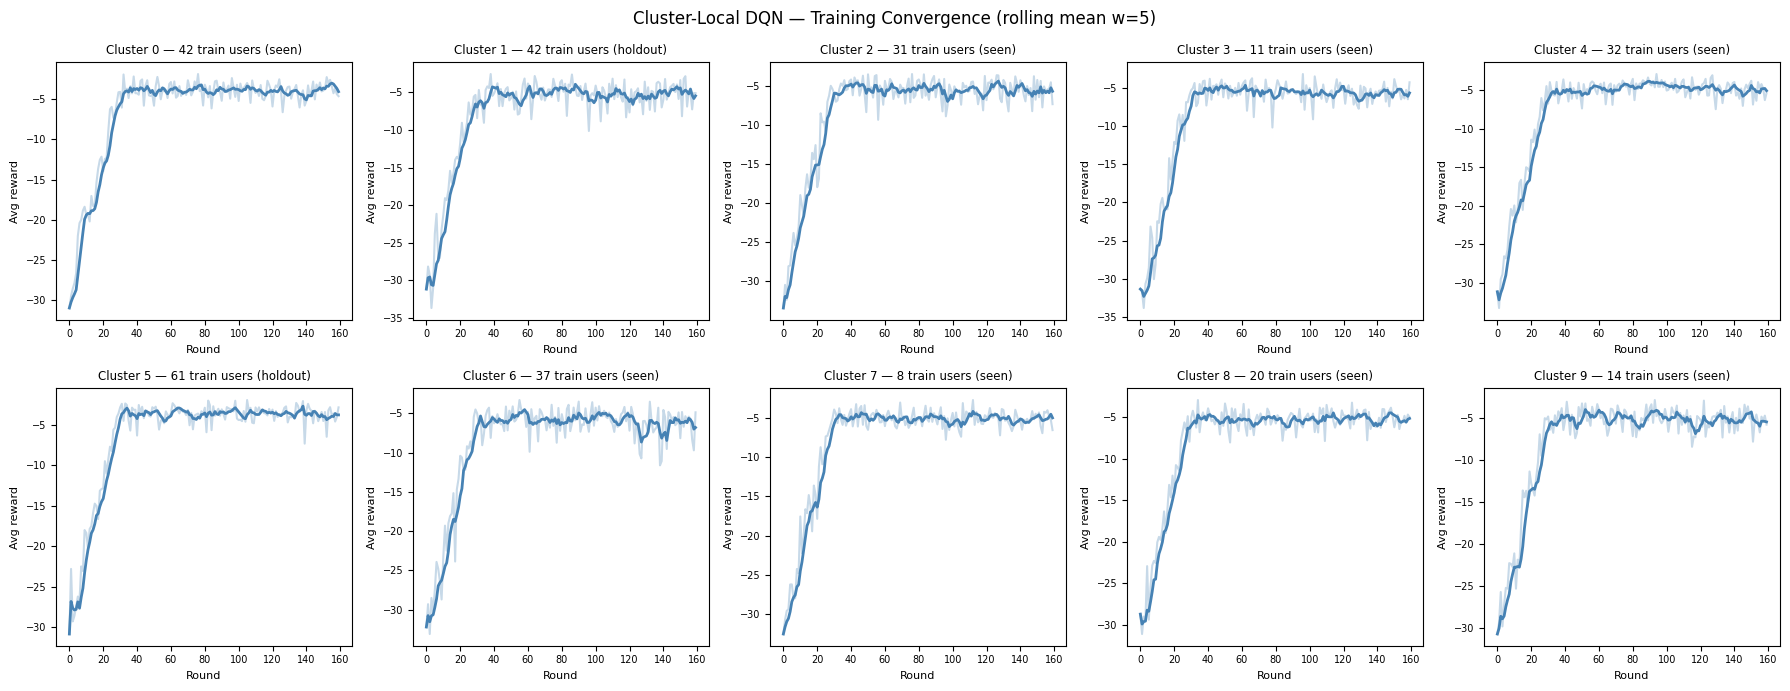

Saved: cluster_dqn_training.png


In [9]:
n_clusters = len(all_cluster_ids)
n_cols     = 5
n_rows     = (n_clusters + n_cols - 1) // n_cols
window     = 5

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 3.5 * n_rows))
axes = axes.flatten()

for i, c in enumerate(all_cluster_ids):
    ax      = axes[i]
    rewards = cluster_rewards[c]
    trend   = pd.Series(rewards).rolling(window=window, min_periods=1).mean().tolist()
    ax.plot(rewards, alpha=0.3, color='steelblue')
    ax.plot(trend, linewidth=2, color='steelblue')
    n_train = len(cluster_train_uids[c])
    tag     = ' (holdout)' if c in top_clusters else ' (seen)'
    ax.set_title(f'Cluster {c} — {n_train} train users{tag}', fontsize=8.5)
    ax.set_xlabel('Round', fontsize=8)
    ax.set_ylabel('Avg reward', fontsize=8)
    ax.tick_params(labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Cluster-Local DQN — Training Convergence (rolling mean w=5)', fontsize=12)
plt.tight_layout()
plt.savefig('cluster_dqn_training.png', dpi=150)
plt.show()
print('Saved: cluster_dqn_training.png')

## Cell 9 — Evaluate each cluster agent

For each cluster:
- **DQN**: greedy rollout on the eval user's test split (last 1/3)
- **No-battery baseline**: same test split, battery capacity = 0, always idle action
- **MILP**: continuous LP with perfect foresight (theoretical optimum)

In [10]:
def evaluate_user(agent, uid, cluster_id):
    """Greedy DQN rollout on the test split. Returns total cost (AUD)."""
    env = make_env(uid, cluster_id, split='test')
    obs, _ = env.reset(options={'reset_mode': 'deterministic'})

    saved_eps     = agent.epsilon
    agent.epsilon = 0.0
    last_info     = {}

    for _ in range(len(test_dfs[uid]) - 1):
        action = agent.choose_action(obs)
        obs, _, terminated, truncated, info = env.step(action)
        last_info = info
        if terminated or truncated:
            break

    agent.epsilon = saved_eps
    return float(last_info.get('cumulative_payment', 0.0))


def no_battery_baseline(uid, cluster_id):
    """Always idle, no battery. Returns total cost (AUD)."""
    env = HouseholdEnvironment(
        dataset            = test_dfs[uid],
        dataset_norm       = cluster_test_norm_dfs[cluster_id][uid],
        observation_mode   = 'sliding_window',
        reset_mode         = 'deterministic',
        episode_length     = len(test_dfs[uid]) - 1,
        korakov_na_dan     = KorakovNaDan,
        bat_kapaciteta     = 0,
        bat_ucinkovitost   = BatUcinkovitost,
        bat_max_polnjenje  = BatMaxPolnjenje,
        bat_max_praznjenje = BatMaxPraznjenje,
        faktor_n1 = faktorN1,
        faktor_n2 = faktorN2,
        faktor_n3 = faktorN3,
    )
    obs, _ = env.reset(options={'reset_mode': 'deterministic'})
    last_info = {}
    for _ in range(len(test_dfs[uid]) - 1):
        obs, _, terminated, truncated, last_info = env.step(4)
        if terminated or truncated:
            break
    return float(last_info.get('cumulative_payment', 0.0))


def run_milp(uid, cluster_id):
    """Perfect-foresight MILP on the test split — theoretical optimum.

    Thin wrapper around the shared Basic_Functions.run_milp_benchmark
    implementation (same formulation as all the other notebooks).
    """
    env = HouseholdEnvironment(
        dataset            = test_dfs[uid],
        dataset_norm       = cluster_test_norm_dfs[cluster_id][uid],
        observation_mode   = 'sliding_window',
        reset_mode         = 'deterministic',
        episode_length     = len(test_dfs[uid]) - 1,
        korakov_na_dan     = KorakovNaDan,
        bat_kapaciteta     = BatKapaciteta,
        bat_ucinkovitost   = BatUcinkovitost,
        bat_max_polnjenje  = BatMaxPolnjenje,
        bat_max_praznjenje = BatMaxPraznjenje,
        faktor_n1 = faktorN1,
        faktor_n2 = faktorN2,
        faktor_n3 = faktorN3,
    )
    return milp_total_cost(env, problem_name=f'MG_U{uid}_C{cluster_id}')


print('Evaluating cluster agents on their designated eval users...')
eval_results = []

for c in all_cluster_ids:
    uid   = cluster_eval_uid[c]
    group = 'holdout' if c in top_clusters else 'seen'
    print(f'  Cluster {c:2d}: user {uid:3d} ({group})...')

    dqn_cost  = evaluate_user(cluster_agents[c], uid, c)
    base_cost = no_battery_baseline(uid, c)
    milp_cost = run_milp(uid, c)

    print(f'    Baseline: {base_cost:8.2f} AUD  '
          f'DQN: {dqn_cost:8.2f} AUD  '
          f'MILP: {milp_cost:8.2f} AUD')

    eval_results.append({
        'cluster':  c,
        'uid':      uid,
        'group':    group,
        'n_train':  len(cluster_train_uids[c]),
        'baseline': base_cost,
        'dqn':      dqn_cost,
        'milp':     milp_cost,
    })

df_eval = pd.DataFrame(eval_results)
df_eval['imp_dqn_%']           = ((df_eval['baseline'] - df_eval['dqn'])  /
                                   df_eval['baseline'].abs() * 100).round(1)
df_eval['imp_milp_%']          = ((df_eval['baseline'] - df_eval['milp']) /
                                   df_eval['baseline'].abs() * 100).round(1)
df_eval['gap_dqn_vs_milp_%']   = ((df_eval['dqn']      - df_eval['milp']) /
                                   df_eval['milp'].abs() * 100).round(1)
df_eval['frac_theor_%']        = ((df_eval['baseline']  - df_eval['dqn'])  /
                                  (df_eval['baseline']   - df_eval['milp']) * 100).round(1)

print('\nEvaluation complete.')

Evaluating cluster agents on their designated eval users...
  Cluster  0: user 259 (seen)...
    Baseline:   945.47 AUD  DQN:   868.50 AUD  MILP:   781.41 AUD
  Cluster  1: user  28 (holdout)...
    Baseline:  1093.04 AUD  DQN:  1013.19 AUD  MILP:   863.93 AUD
  Cluster  2: user  31 (seen)...
    Baseline:  1188.03 AUD  DQN:  1058.84 AUD  MILP:   887.49 AUD
  Cluster  3: user 287 (seen)...
    Baseline:  1387.04 AUD  DQN:  1215.51 AUD  MILP:  1021.05 AUD
  Cluster  4: user 243 (seen)...
    Baseline:  1413.24 AUD  DQN:  1127.36 AUD  MILP:   985.59 AUD
  Cluster  5: user  66 (holdout)...
    Baseline:  1000.19 AUD  DQN:   854.66 AUD  MILP:   789.58 AUD
  Cluster  6: user 200 (seen)...
    Baseline:  1650.53 AUD  DQN:  1631.98 AUD  MILP:  1196.95 AUD
  Cluster  7: user 251 (seen)...
    Baseline:  1505.74 AUD  DQN:  1360.94 AUD  MILP:  1106.95 AUD
  Cluster  8: user  78 (seen)...
    Baseline:  1240.86 AUD  DQN:  1076.62 AUD  MILP:   862.86 AUD
  Cluster  9: user 249 (seen)...
    Baseli

## Cell 10 — Results & visualisation

═══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
PER-CLUSTER RESULTS
═══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
 Cluster  Eval User   Group  # Train  No-Battery (AUD)   DQN (AUD)  MILP Optimum (AUD)  DQN impr. %  MILP impr. %  DQN gap vs MILP %  DQN frac. of theor. gain %
       0        259    seen       42        945.470392  868.498988          781.413822          8.1          17.4               11.1                        46.9
       1         28 holdout       42       1093.043263 1013.194984          863.925119          7.3          21.0               17.3                        34.9
       2         31    seen       31       1188.034150 1058.841689          887.487108         10.9          25.3               19.3                        43.0
       3        287    seen       11       1387.038645 1215.5124

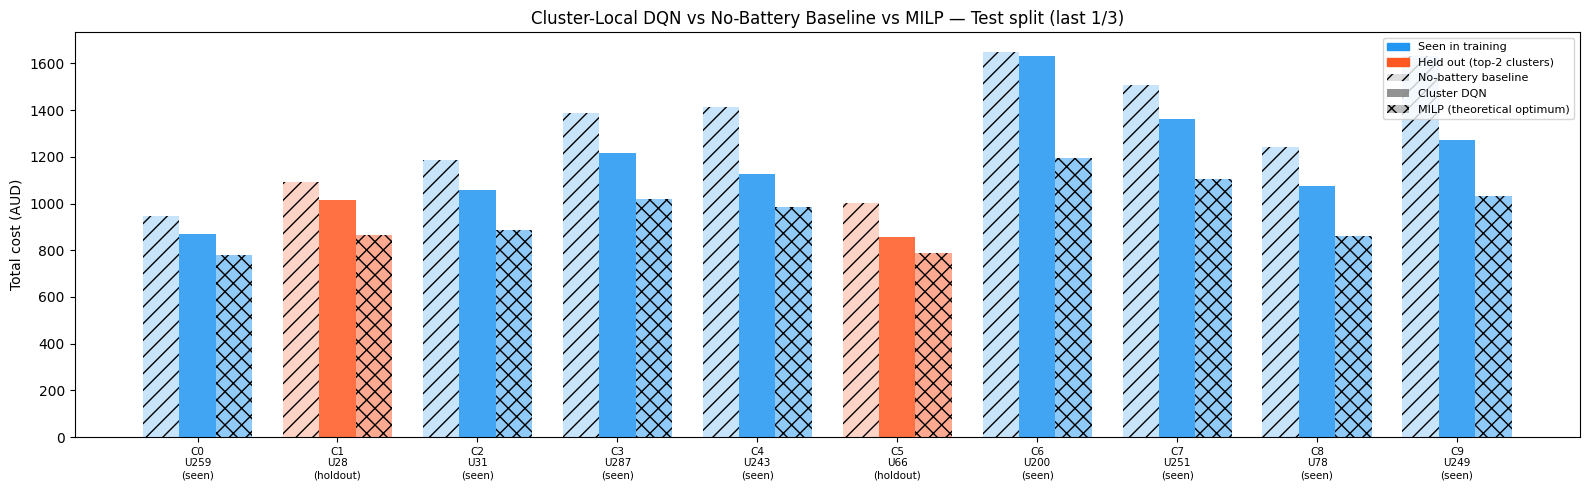

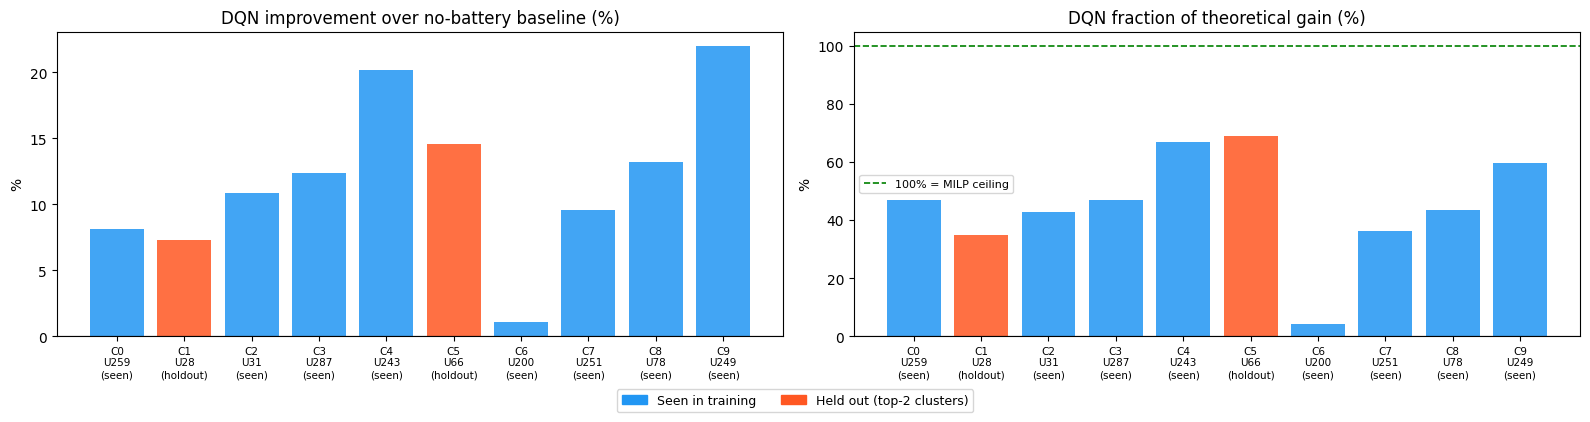

Plots saved: cluster_dqn_costs.png  cluster_dqn_improvement.png  cluster_dqn_training.png


In [11]:
# ── Per-cluster results table ─────────────────────────────────
display_cols = {
    'cluster':           'Cluster',
    'uid':               'Eval User',
    'group':             'Group',
    'n_train':           '# Train',
    'baseline':          'No-Battery (AUD)',
    'dqn':               'DQN (AUD)',
    'milp':              'MILP Optimum (AUD)',
    'imp_dqn_%':         'DQN impr. %',
    'imp_milp_%':        'MILP impr. %',
    'gap_dqn_vs_milp_%': 'DQN gap vs MILP %',
    'frac_theor_%':      'DQN frac. of theor. gain %',
}
df_display = df_eval[list(display_cols.keys())].rename(columns=display_cols)
print('═' * 135)
print('PER-CLUSTER RESULTS')
print('═' * 135)
print(df_display.to_string(index=False))

# ── Summary by group ─────────────────────────────────────────
print('\n' + '═' * 80)
print('GROUP AVERAGES')
print('═' * 80)
for group in ['seen', 'holdout']:
    sub = df_eval[df_eval['group'] == group]
    if sub.empty:
        continue
    print(f'\n{group.upper()} ({len(sub)} cluster(s)):')
    print(f'  Avg DQN improvement over baseline : {sub["imp_dqn_%"].mean():.1f}%')
    print(f'  Avg MILP improvement over baseline: {sub["imp_milp_%"].mean():.1f}%')
    print(f'  Avg DQN gap vs MILP               : {sub["gap_dqn_vs_milp_%"].mean():.1f}%')
    print(f'  Avg DQN fraction of theor. gain   : {sub["frac_theor_%"].mean():.1f}%')

# ── Bar chart: absolute costs ─────────────────────────────────
x          = np.arange(len(df_eval))
width      = 0.26
colors     = {'seen': '#2196F3', 'holdout': '#FF5722'}
bar_colors = [colors[g] for g in df_eval['group']]
xlabels    = [f'C{r.cluster}\nU{r.uid}\n({r.group})' for r in df_eval.itertuples()]

fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(x - width, df_eval['baseline'], width, color=bar_colors, alpha=0.25, hatch='//')
ax.bar(x,         df_eval['dqn'],      width, color=bar_colors, alpha=0.85)
ax.bar(x + width, df_eval['milp'],     width, color=bar_colors, alpha=0.50, hatch='xx')
ax.set_xticks(x)
ax.set_xticklabels(xlabels, fontsize=7.5)
ax.set_ylabel('Total cost (AUD)')
ax.set_title('Cluster-Local DQN vs No-Battery Baseline vs MILP — Test split (last 1/3)')
ax.legend(handles=[
    mpatches.Patch(color=colors['seen'],    label='Seen in training'),
    mpatches.Patch(color=colors['holdout'], label='Held out (top-2 clusters)'),
    mpatches.Patch(facecolor='grey', alpha=0.25, hatch='//', label='No-battery baseline'),
    mpatches.Patch(facecolor='grey', alpha=0.85,              label='Cluster DQN'),
    mpatches.Patch(facecolor='grey', alpha=0.50, hatch='xx',  label='MILP (theoretical optimum)'),
], loc='upper right', fontsize=8)
plt.tight_layout()
plt.savefig('cluster_dqn_costs.png', dpi=150)
plt.show()

# ── Two-panel improvement chart ───────────────────────────────
fig2, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(16, 4))

ax_l.bar(x, df_eval['imp_dqn_%'], color=bar_colors, alpha=0.85)
ax_l.axhline(0, color='black', linewidth=0.8)
ax_l.set_xticks(x)
ax_l.set_xticklabels(xlabels, fontsize=7.5)
ax_l.set_ylabel('%')
ax_l.set_title('DQN improvement over no-battery baseline (%)')

ax_r.bar(x, df_eval['frac_theor_%'], color=bar_colors, alpha=0.85)
ax_r.axhline(0,   color='black', linewidth=0.8)
ax_r.axhline(100, color='green', linewidth=1.2, linestyle='--', label='100% = MILP ceiling')
ax_r.set_xticks(x)
ax_r.set_xticklabels(xlabels, fontsize=7.5)
ax_r.set_ylabel('%')
ax_r.set_title('DQN fraction of theoretical gain (%)')
ax_r.legend(fontsize=8)

fig2.legend(handles=[
    mpatches.Patch(color=colors['seen'],    label='Seen in training'),
    mpatches.Patch(color=colors['holdout'], label='Held out (top-2 clusters)'),
], loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.06), fontsize=9)
plt.tight_layout()
plt.savefig('cluster_dqn_improvement.png', dpi=150)
plt.show()

print('Plots saved: cluster_dqn_costs.png  cluster_dqn_improvement.png  cluster_dqn_training.png')